# CD-ADAPT-VQE en grafos completos $K_n$


Analiza los resultados de **CD-ADAPT-VQE** sobre **grafos completos $K_n$**, para $n = 4, \dots, 10$, comparando el pool de operadores de orden $\ell=1$ (solo $O_1$) contra $\ell=2$ ($O_1+O_3$).

Los datos se generaron corriendo `cluster/run_kn.py` dos veces:

```
python run_kn.py --l 1 --n_min 4 --n_max 10
python run_kn.py --l 2 --n_min 4 --n_max 10
```

A diferencia de los demás cuadernillos, acá **no se usa ningún archivo de `datos/`**: los grafos $K_n$ (completos) se generan internamente en `run_kn.py`.

Los resultados quedaron guardados en:
- `resultados/csv/kn_l1_n4-10.csv`, `resultados/json/kn_l1_n4-10.json`
- `resultados/csv/kn_l2_n4-10.csv`, `resultados/json/kn_l2_n4-10.json`


## 0. Set-up

In [8]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")

mpl.rcParams.update({
    "figure.dpi"       : 120,
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.color"       : "#DDDDDD",
    "grid.linewidth"   : 0.6,
    "grid.alpha"       : 1.0,
    "font.family"      : "serif",
    "font.size"        : 11,
    "axes.labelsize"   : 11,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "legend.fontsize"  : 10,
    "legend.framealpha": 0.9,
    "legend.edgecolor" : "#BBBBBB",
    "xtick.labelsize"  : 10,
    "ytick.labelsize"  : 10,
    "lines.linewidth"  : 2.0,
    "patch.linewidth"  : 0.4,
    "savefig.dpi"      : 150,
    "savefig.bbox"     : "tight",
    "savefig.facecolor": "white",
})

C1 = "#0072B2"   # blue      — l = 1
C2 = "#D55E00"   # vermilion — l = 2

PROJECT_ROOT  = Path("..").resolve()
CSV_DIR       = PROJECT_ROOT / "resultados" / "csv"
JSON_DIR      = PROJECT_ROOT / "resultados" / "json"


## 1. Carga de datos

Acá solo se cargan los datos: se leen los CSV/JSON que generó `run_kn.py` para $\ell=1$ y $\ell=2$, y se verifica cuántos grafos $K_n$ distintos llegaron efectivamente desde el cluster para cada orden del pool.

In [9]:
def _find_result_file(directory, pattern):
    matches = sorted(directory.glob(pattern))
    if not matches:
        print(f"[AVISO] No se encontró ningún archivo con patrón: {pattern}")
        return None
    if len(matches) > 1:
        print(f"[AVISO] Hay {len(matches)} archivos que matchean '{pattern}', usando: {matches[0].name}")
    return matches[0]


def load_csv(l):
    path = _find_result_file(CSV_DIR, f"kn_l{l}_n*-*.csv")
    if path is None:
        return None
    df = pd.read_csv(path)
    df["l"] = l
    for col in ["E_final", "diferencia", "ratio_E_E0",
                "grad_final_norm", "runtime_min"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def load_json(l):
    path = _find_result_file(JSON_DIR, f"kn_l{l}_n*-*.json")
    if path is None:
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


df1 = load_csv(1)
df2 = load_csv(2)

json1 = load_json(1)
json2 = load_json(2)

# DataFrame combinado para gráficos comparativos
frames = [df for df in [df1, df2] if df is not None]
df_all = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print(f"Filas cargadas: l=1 → {len(df1) if df1 is not None else 0}  |  l=2 → {len(df2) if df2 is not None else 0}")

Filas cargadas: l=1 → 4  |  l=2 → 4


## 2. Gráficos de comparación global

In [10]:

COLORS = {1: C1, 2: C2}
MARKERS = {1: "o", 2: "s"}

def subset(l):
    return df_all[df_all["l"] == l].sort_values("n")

**Gráfico 1 — Razón de energía final / exacta.** Qué tan cerca del ground state exacto ($E_{final}/E_0 \to 1$) termina el algoritmo para cada $n$, comparando $\ell=1$ contra $\ell=2$.

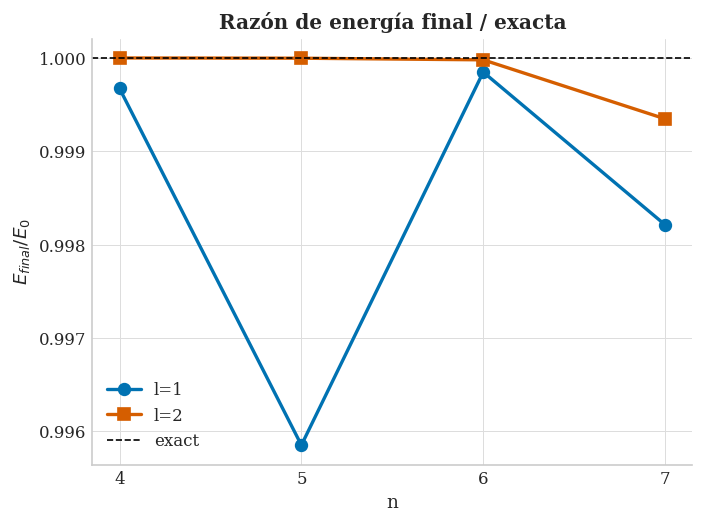

In [11]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for l in [1, 2]:
    d = subset(l)
    if not d.empty:
        ax.plot(d["n"], d["ratio_E_E0"], marker=MARKERS[l], color=COLORS[l],
                label=f"l={l}", linewidth=2, markersize=7)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="exact")
ax.set_xlabel("n")
ax.set_ylabel("$E_{final} / E_0$")
ax.set_title("Razón de energía final / exacta")
ax.legend()
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

**Gráfico 2 — Iteraciones ADAPT hasta convergencia.** Cuántos operadores tuvo que agregar el ansatz (iteraciones ADAPT) antes de que la norma del gradiente cayera bajo el umbral, en función de $n$, para cada orden del pool.

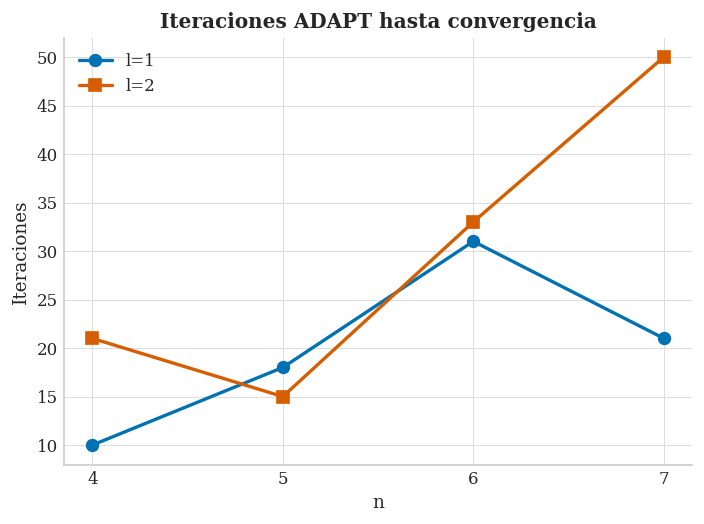

In [12]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for l in [1, 2]:
    d = subset(l)
    if not d.empty:
        ax.plot(d["n"], d["iteraciones"], marker=MARKERS[l], color=COLORS[l],
                label=f"l={l}", linewidth=2, markersize=7)
ax.set_xlabel("n")
ax.set_ylabel("Iteraciones")
ax.set_title("Iteraciones ADAPT hasta convergencia")
ax.legend()
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

**Gráfico 3 — Tamaño del pool de operadores.** Cuántos operadores hay disponibles para elegir en cada paso ADAPT ($\ell=1$ vs $\ell=2$) según $n$ — mide cómo escala el espacio de búsqueda del ansatz, independiente de cuántos termine usando.

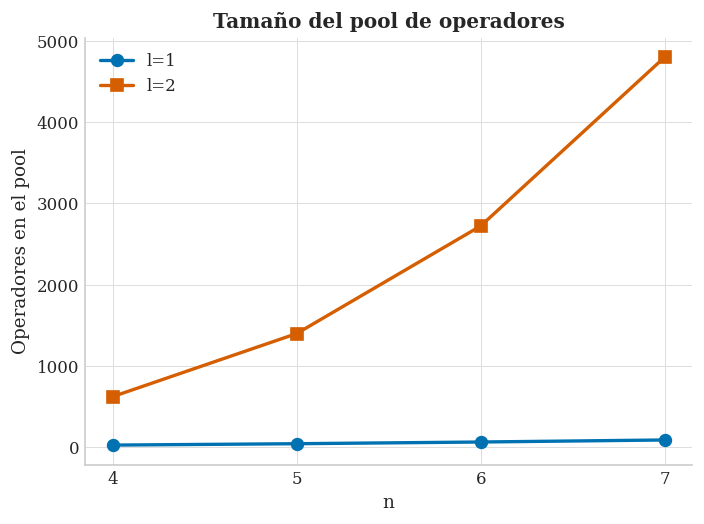

In [13]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for l in [1, 2]:
    d = subset(l)
    if not d.empty:
        ax.plot(d["n"], d["pool_size"], marker=MARKERS[l], color=COLORS[l],
                label=f"l={l}", linewidth=2, markersize=7)
ax.set_xlabel("n")
ax.set_ylabel("Operadores en el pool")
ax.set_title("Tamaño del pool de operadores")
ax.legend()
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

**Gráfico 4 — Tiempo de ejecución.** Cuánto tardó en minutos correr el algoritmo completo para cada $n$ y cada $\ell$ — el costo computacional real, que no siempre escala igual que el número de iteraciones (el tamaño del pool también pesa).

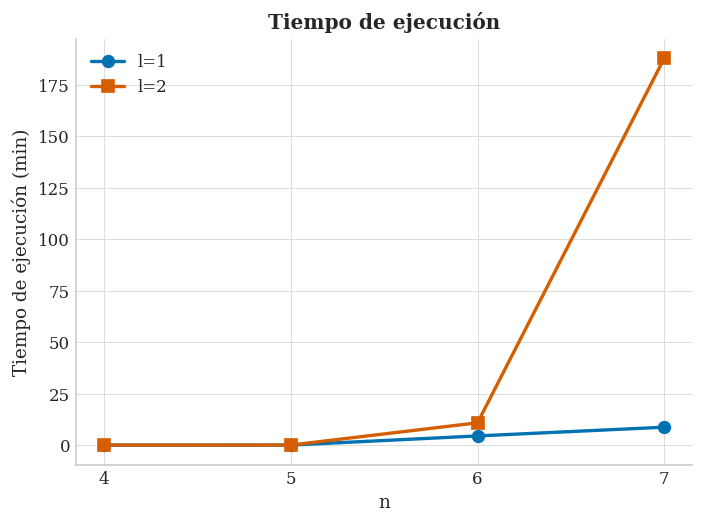

In [14]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for l in [1, 2]:
    d = subset(l)
    if not d.empty:
        ax.plot(d["n"], d["runtime_min"], marker=MARKERS[l], color=COLORS[l],
                label=f"l={l}", linewidth=2, markersize=7)
ax.set_xlabel("n")
ax.set_ylabel("Tiempo de ejecución (min)")
ax.set_title("Tiempo de ejecución")
ax.legend()
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()